In [46]:
import jax
import jax.numpy as jnp
import numpy as np
from jax.scipy.integrate import trapezoid
from jax import grad
import matplotlib.pyplot as plt

print("JAX version:", jax.__version__)
print("NumPy version:", np.__version__)

JAX version: 0.7.0
NumPy version: 2.3.3


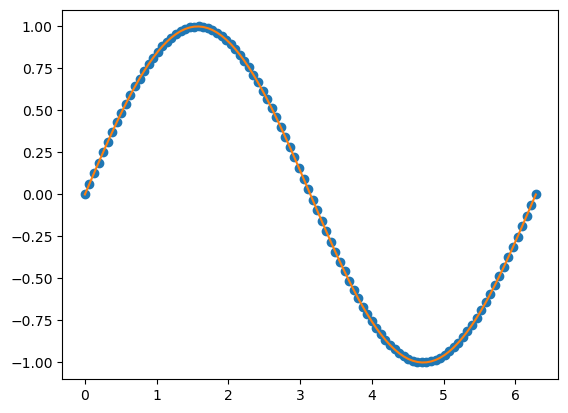

In [10]:
x_numpy = np.linspace(0, 2 * np.pi, 100)
x_jax = jnp.linspace(0, 2 * jnp.pi, 100)

y_jax = jnp.sin(x_jax)
y_numpy = np.sin(x_numpy)

plt.plot(x_numpy, y_numpy, 'o', label='NumPy')
plt.plot(x_jax, y_jax, label='JAX')

In [11]:
print(f"Numpy array type: {type(x_numpy)}")
print(f"JAX array type: {type(x_jax)}")

Numpy array type: <class 'numpy.ndarray'>
JAX array type: <class 'jaxlib._jax.ArrayImpl'>


In [12]:
print("JAX arrays are NOT mutable.")

numpy_array = np.array([1, 2, 3])
print(f"Initial array: {numpy_array}")
numpy_array[0] = 10
print(f"Modified array: {numpy_array}")

jax_array = jnp.array([1, 2, 3])
print(f"Initial array: {jax_array}")
try:
    jax_array[0] = 10
except Exception as e:
    print(f"Error: {e}")
finally:
    jax_array_modif = jax_array.at[0].set(10)
print(f"Modified array: {jax_array_modif}")
print(f"Initial array: {jax_array}")

JAX arrays are NOT mutable.
Initial array: [1 2 3]
Modified array: [10  2  3]
Initial array: [1 2 3]
Error: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html
Modified array: [10  2  3]
Initial array: [1 2 3]


In [13]:
jax_array.devices()

{CpuDevice(id=0)}

# Harmonic oscillator

norm: 1.0


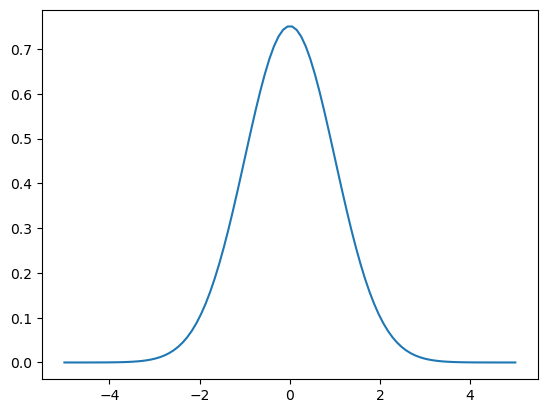

In [14]:
def qho_wf(x):
    return jnp.exp(-0.5 * x**2)*jnp.pi**(-0.25)

x_linspace = jnp.linspace(-5, 5, 100)

print(f"norm: {jnp.sqrt(trapezoid(qho_wf(x_linspace)**2, x_linspace))}")

plt.plot(x_linspace, qho_wf(x_linspace)) 

In [15]:
from jax import grad

def hami(x):
    kinetic = -0.5 * jnp.gradient(jnp.gradient(qho_wf(x), x),x)
    potential = 0.5 * x**2 * qho_wf(x)
    return kinetic + potential



def energy(hami):
    x_trapzs = jnp.linspace(-100,100,1000000)
    return trapezoid(qho_wf(x_trapzs)*hami(x_trapzs), x_trapzs)/jnp.sqrt(trapezoid(qho_wf(x_trapzs)**2, x_trapzs))
print(energy(hami))

0.50706965


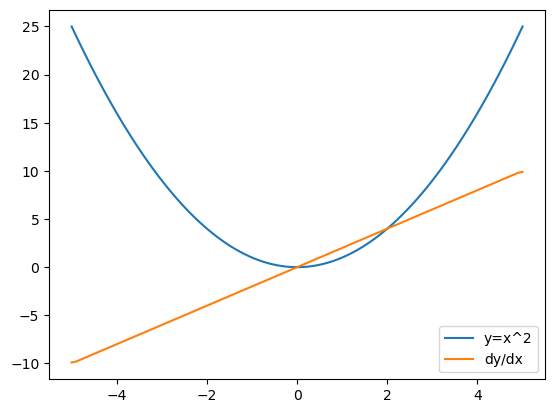

In [16]:
x_squared_poly = jnp.linspace(-5, 5, 100)
y_squared_poly = x_squared_poly**2
d_y_d_x = jnp.gradient(y_squared_poly, x_squared_poly)
plt.plot(x_squared_poly, y_squared_poly, label='y=x^2')
plt.plot(x_squared_poly, d_y_d_x, label='dy/dx')
plt.legend()

In [19]:
def linear_layer(input, weights, bias):
    return jnp.dot(input, weights) + bias

def mlp(input, weights, hidden_activation = jnp.tanh, output_activation = jnp.tanh):
    hidden_layers = weights["hidden"]
    output_layer = weights["output"]
    for layer in hidden_layers:
        input = linear_layer(input, layer['weights'], layer['bias'])
        input = hidden_activation(input)
    input = linear_layer(input, output_layer['weights'], output_layer['bias'])
    return output_activation(input)

dict_weights = {
    "hidden": [
        {"weights": jax.random.normal(jax.random.PRNGKey(0), (input_dim, hidden_dim)), "bias": jnp.zeros(hidden_dim)},
        {"weights": jax.random.normal(jax.random.PRNGKey(1), (hidden_dim, hidden_dim)), "bias": jnp.zeros(hidden_dim)},
    ],
    "output": {"weights": jax.random.normal(jax.random.PRNGKey(2), (hidden_dim, output_dim)), "bias": jnp.zeros(output_dim)},
}

NameError: name 'input_dim' is not defined

In [20]:
import flax.nnx as nnx
import optax

# QHO with JAX environment and trapezoid rule for the integral

### Optimizer

In [21]:
optimizer = optax.adam(learning_rate=1e-3)

### Model

In [22]:
class MLP(nnx.Module):
    def __init__(self, architecture, hidden_activation, rngs = nnx.Rngs(42)):
        self.layers = []
        for i,layer in enumerate(architecture[:-1]):
             in_dimension = layer
             out_dimension = architecture[i+1]
             self.layers.append(nnx.Linear(in_features=in_dimension, out_features=out_dimension, rngs=rngs))
             self.layers.append(hidden_activation)

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [46]:
nnx.display(MLP(architecture=[1, 2, 1], hidden_activation=nnx.tanh))

MLP(
  layers=[Linear(
    kernel=Param(
      value=Array(shape=(1, 2), dtype=float32)
    ),
    bias=Param(
      value=Array(shape=(2,), dtype=float32)
    ),
    in_features=1,
    out_features=2,
    use_bias=True,
    dtype=None,
    param_dtype=<class 'jax.numpy.float32'>,
    precision=None,
    kernel_init=<function variance_scaling.<locals>.init at 0x7ceb301b0220>,
    bias_init=<function zeros at 0x7ceb70402520>,
    dot_general=<function dot_general at 0x7cec080ef4c0>
  ), <PjitFunction of <function tanh at 0x7ceb7067d300>>, Linear(
    kernel=Param(
      value=Array(shape=(2, 1), dtype=float32)
    ),
    bias=Param(
      value=Array([0.], dtype=float32)
    ),
    in_features=2,
    out_features=1,
    use_bias=True,
    dtype=None,
    param_dtype=<class 'jax.numpy.float32'>,
    precision=None,
    kernel_init=<function variance_scaling.<locals>.init at 0x7ceb301b0220>,
    bias_init=<function zeros at 0x7ceb70402520>,
    dot_general=<function dot_general at 0x7cec0

# Gradient computation

In [32]:
x_linspace = jnp.linspace(-5,5,1000)

class squared_poly(nnx.Module):
    def __init__(self, a):
        self.a = a
    def __call__(self, x):
        return self.a * x**2

model = squared_poly(1.0)
x_linspace = x_linspace.reshape(-1,1)
gradient = grad(model)

gradients = jax.vmap(gradient)(x_linspace)

print(gradients)

TypeError: Gradient only defined for scalar-output functions. Output had shape: (1,).

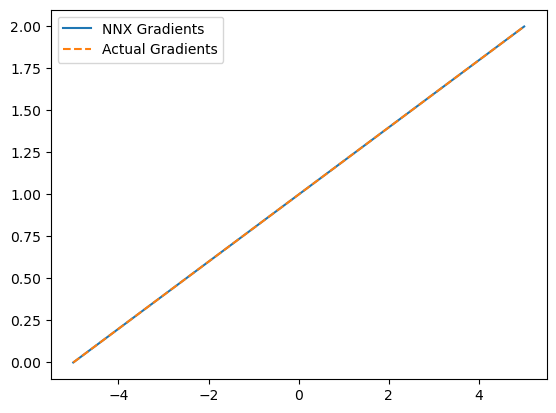

In [41]:
import jax
import jax.numpy as jnp
from flax import nnx
from jax import grad, vmap

# Input grid
x_linspace = jnp.linspace(-5, 5, 1000).reshape(-1,1)

# Define NNX module
class SquaredPoly(nnx.Module):
    def __init__(self, a, b, c):
        # Make 'a', 'b', and 'c' JAX arrays
        self.a = jnp.array(a)
        self.b = jnp.array(b)
        self.c = jnp.array(c)
    def __call__(self, x):
        return self.a * x**2 + self.b * x + self.c

# Instantiate module
a, b, c = 0.1, 1.0, 0.0
model = SquaredPoly(a, b, c)

# Define gradient function using the module's __call__
def gradient_fn(x):
    # grad expects a scalar output, so squeeze if needed
    return grad(lambda x_: model(x_).squeeze())(x)

# Vectorize over batch
gradients = jax.vmap(gradient_fn)(x_linspace)

def actual_gradient(x, a=0.1, b=1.0):
    return 2 * a * x + b

plt.plot(x_linspace, gradients)
plt.plot(x_linspace, actual_gradient(x_linspace, a, b), linestyle='dashed')
plt.legend(['NNX Gradients', 'Actual Gradients'])

In [42]:
import jax
import jax.numpy as jnp
from flax import nnx
from jax import grad, vmap
import matplotlib.pyplot as plt

# Input grid
x_linspace = jnp.linspace(-5, 5, 1000).reshape(-1,1)

# Define NNX module with parameters
class SquaredPolyNNX(nnx.Module):
    def __init__(self):
        # Define learnable parameters as nnx.Parameter
        self.a = nnx.Parameter(jnp.array(0.1))
        self.b = nnx.Parameter(jnp.array(1.0))
        self.c = nnx.Parameter(jnp.array(0.0))
    
    def __call__(self, x):
        # x can be batched: shape (batch, 1)
        return self.a * x**2 + self.b * x + self.c

# Instantiate module
model = SquaredPolyNNX()

# Helper: compute gradients w.r.t input and parameters
def grad_fn(x):
    # grad w.r.t (x, a, b, c)
    return jax.grad(lambda x_, a, b, c: model.__call__(x_).squeeze(),
                     argnums=(0,1,2,3))(
        x, model.a, model.b, model.c
    )

# Vectorize over batch
gradients = vmap(grad_fn)(x_linspace)
dx, da, db, dc = gradients[:,0], gradients[:,1], gradients[:,2], gradients[:,3]

# Plot results
plt.plot(x_linspace, dx, label='d/dx')
plt.plot(x_linspace, da, label='d/da')
plt.plot(x_linspace, db, label='d/db')
plt.plot(x_linspace, dc, label='d/dc')
plt.legend()
plt.show()

AttributeError: module 'flax.nnx' has no attribute 'Parameter'

In [47]:
class MLP(nnx.Module):
    def __init__(self, architecture, hidden_activation, rngs = nnx.Rngs(42)):
        self.layers = []
        for i,layer in enumerate(architecture[:-1]):
             in_dimension = layer
             out_dimension = architecture[i+1]
             self.layers.append(nnx.Linear(in_features=in_dimension, out_features=out_dimension, rngs=rngs))
             self.layers.append(hidden_activation)

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
nnx.display(MLP(architecture=[1, 2, 1], hidden_activation=nnx.tanh))    

MLP(
  layers=[Linear(
    kernel=Param(
      value=Array(shape=(1, 2), dtype=float32)
    ),
    bias=Param(
      value=Array(shape=(2,), dtype=float32)
    ),
    in_features=1,
    out_features=2,
    use_bias=True,
    dtype=None,
    param_dtype=<class 'jax.numpy.float32'>,
    precision=None,
    kernel_init=<function variance_scaling.<locals>.init at 0x7ceb301b0220>,
    bias_init=<function zeros at 0x7ceb70402520>,
    dot_general=<function dot_general at 0x7cec080ef4c0>
  ), <PjitFunction of <function tanh at 0x7ceb7067d300>>, Linear(
    kernel=Param(
      value=Array(shape=(2, 1), dtype=float32)
    ),
    bias=Param(
      value=Array([0.], dtype=float32)
    ),
    in_features=2,
    out_features=1,
    use_bias=True,
    dtype=None,
    param_dtype=<class 'jax.numpy.float32'>,
    precision=None,
    kernel_init=<function variance_scaling.<locals>.init at 0x7ceb301b0220>,
    bias_init=<function zeros at 0x7ceb70402520>,
    dot_general=<function dot_general at 0x7cec0

In [52]:
gradients = nnx.grad(MLP(architecture=[1, 2, 1], hidden_activation=nnx.tanh))
gradients(1.0)

TypeError: dot_general requires lhs dimension numbers to be nonnegative and less than the number of axes of the lhs value, got lhs_batch of () and lhs_contracting of (-1,) for lhs of rank 0

In [59]:
import jax
import jax.numpy as jnp
from flax import nnx

# Define MLP
class MLP(nnx.Module):import jax
import jax.numpy as jnp
from flax import nnx

# Define MLP
class MLP(nnx.Module):
    def __init__(self, architecture, hidden_activation, rngs=nnx.Rngs(42)):
        self.layers = []
        for i in range(len(architecture)-1):
            in_dim = architecture[i]
            out_dim = architecture[i+1]
            self.layers.append(nnx.Linear(in_features=in_dim, out_features=out_dim, rngs=rngs))
            # Only add hidden activation if not last layer
            if i < len(architecture)-2:
                self.layers.append(hidden_activation)
        # Note: last layer has no activation

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Instantiate model
model = MLP([2,2,30,1], nnx.tanh)

# Wrap model call in a function for grad
def f(x):
    x_in = x[None, :] 
    y = model(x_in)
    print(y)
    return y[0,0]  # scalar output required for grad

# Compute gradient w.r.t input
grad_f = jax.grad(f)
print(grad_f(jnp.array([1.0,2.0])))

LinearizeTracer<float32[1,1]>
[ 0.06982972 -0.07027546]


In [64]:
import jax
import jax.numpy as jnp
from flax import nnx

# Define MLP
class MLP(nnx.Module):
    def __init__(self, architecture, hidden_activation, rngs=nnx.Rngs(42)):
        self.layers = []
        for i in range(len(architecture)-1):
            in_dim = architecture[i]
            out_dim = architecture[i+1]
            self.layers.append(nnx.Linear(in_features=in_dim, out_features=out_dim, rngs=rngs))
            if i < len(architecture)-2:
                self.layers.append(hidden_activation)

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Instantiate model
model = MLP([2, 1, 1], nnx.tanh)

# Split params/state
params, state = nnx.split(model, nnx.Param)

# Function: model output (scalar) for a single input
def f_single(params, state, x):
    model = nnx.merge(params, state)
    y = model(x[None, :])       # keep batch dim
    return y[0,0]               # must be scalar for grad

In [67]:
grad_fn_single = jax.grad(f_single)
x0 = jnp.array([1.0, 2.0])
grads = grad_fn_single(params, state, x0)

# print(jax.tree_util.tree_map(lambda g: g.shape, grads))
print(grads)

NodeDef(
  type=MLP,
  index=0,
  attributes=('layers',),
  subgraphs={
    'layers': NodeDef(
      type=list,
      index=-1,
      attributes=(0, 1, 2),
      subgraphs={
        0: NodeDef(
          type=Linear,
          index=1,
          attributes=('bias', 'bias_init', 'dot_general', 'dtype', 'in_features', 'kernel', 'kernel_init', 'out_features', 'param_dtype', 'precision', 'use_bias'),
          subgraphs={
            'dtype': NodeDef(
              type=NoneType,
              index=-1,
              attributes=(),
              subgraphs={},
              static_fields={},
              leaves={},
              metadata=None,
              index_mapping=None
            ),
            'precision': NodeDef(
              type=NoneType,
              index=-1,
              attributes=(),
              subgraphs={},
              static_fields={},
              leaves={},
              metadata=None,
              index_mapping=None
            )
          },
          stat

In [68]:
# Print gradients
print("Gradient values:")
jax.tree_util.tree_map(lambda g: print(g.shape, "\n", g), grads)

Gradient values:


NodeDef(
  type=MLP,
  index=0,
  attributes=('layers',),
  subgraphs={
    'layers': NodeDef(
      type=list,
      index=-1,
      attributes=(0, 1, 2),
      subgraphs={
        0: NodeDef(
          type=Linear,
          index=1,
          attributes=('bias', 'bias_init', 'dot_general', 'dtype', 'in_features', 'kernel', 'kernel_init', 'out_features', 'param_dtype', 'precision', 'use_bias'),
          subgraphs={
            'dtype': NodeDef(
              type=NoneType,
              index=-1,
              attributes=(),
              subgraphs={},
              static_fields={},
              leaves={},
              metadata=None,
              index_mapping=None
            ),
            'precision': NodeDef(
              type=NoneType,
              index=-1,
              attributes=(),
              subgraphs={},
              static_fields={},
              leaves={},
              metadata=None,
              index_mapping=None
            )
          },
          stat

In [79]:
# Compute gradients w.r.t. weights for each input in a batch using JAX and Flax NNx
import jax
import jax.numpy as jnp
from flax import nnx

# Define MLP model
class MLP(nnx.Module):
    def __init__(self, architecture, hidden_activation, rngs=nnx.Rngs(42)):
        self.layers = []
        for i in range(len(architecture)-1):
            in_dim = architecture[i]
            out_dim = architecture[i+1]
            self.layers.append(nnx.Linear(in_features=in_dim, out_features=out_dim, rngs=rngs))
            if i < len(architecture)-2:
                self.layers.append(hidden_activation)
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Instantiate model
model = MLP([1, 1, 1], nnx.tanh)
params, state = nnx.split(model, nnx.Param)

# Function to compute output for a single input
def model_output(params, state, x):
    model = nnx.merge(params, state)
    y = model(x[None, :])  # keep batch dim
    return y[0, 0]         # scalar output for grad

# Gradient function w.r.t. params for a single input
grad_fn = jax.grad(model_output, argnums=0)

# Vectorize over batch
def grads_for_batch(params, state, batch_x):
    return jax.vmap(lambda x: grad_fn(params, state, x))(batch_x)

# Example batch
batch_x = jnp.array([1.0])
grads = grads_for_batch(params, state, batch_x)
print('Gradients w.r.t. weights for each input in batch:')

def print_pytree(pytree, prefix=''):
    if isinstance(pytree, dict):
        for k, v in pytree.items():
            print_pytree(v, prefix + str(k) + '/')
    elif isinstance(pytree, (list, tuple)):
        for i, v in enumerate(pytree):
            print_pytree(v, prefix + str(i) + '/')
    elif hasattr(pytree, 'shape') and hasattr(pytree, 'dtype'):
        arr = jnp.asarray(pytree)
        print(f'{prefix} shape={arr.shape}, dtype={arr.dtype}\n{arr}')
    else:
        print(f'{prefix} {pytree}')

print(grads)
print_pytree(grads)

IndexError: Too many indices: 0-dimensional array indexed with 1 regular index.

In [75]:
# Minimal example: print gradients as a flat list for each input in the batch
import jax
import jax.numpy as jnp
from flax import nnx

# Model definition (reuse previous MLP)
class MLP(nnx.Module):
    def __init__(self, architecture, hidden_activation, rngs=nnx.Rngs(42)):
        self.layers = []
        for i in range(len(architecture)-1):
            in_dim = architecture[i]
            out_dim = architecture[i+1]
            self.layers.append(nnx.Linear(in_features=in_dim, out_features=out_dim, rngs=rngs))
            if i < len(architecture)-2:
                self.layers.append(hidden_activation)
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

model = MLP([2, 3, 1], nnx.tanh)
params, state = nnx.split(model, nnx.Param)

def model_output(params, state, x):
    model = nnx.merge(params, state)
    y = model(x[None, :])
    return y[0, 0]

# Gradient function w.r.t. params for a single input
def grad_flat(params, state, x):
    grads = jax.grad(model_output, argnums=0)(params, state, x)
    flat_grads, _ = jax.tree_util.tree_flatten(grads)
    flat_grads = [jnp.ravel(g) for g in flat_grads]
    flat_grads = jnp.concatenate(flat_grads)
    return flat_grads

# Vectorize over batch
batch_x = jnp.array([[1.0, 2.0]])
flat_grads_batch = jax.vmap(lambda x: grad_flat(params, state, x))(batch_x)

for i, flat_grads in enumerate(flat_grads_batch):
    print(f'grad_theta(f(x_{i})) = {flat_grads.tolist()}')

ValueError: Need at least one array to concatenate.

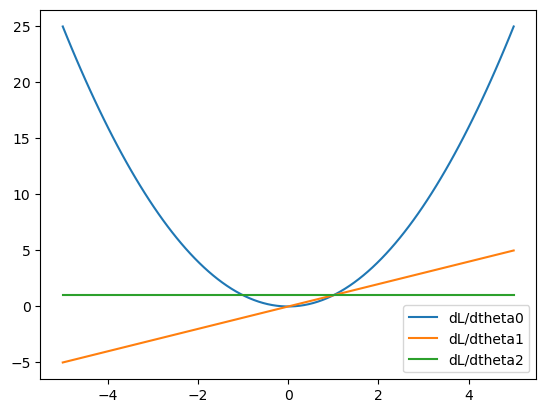

In [ ]:
import jax
import jax.numpy as jnp

# Define a function f(theta, x)
def f(theta, x):
    return theta[0] * x**2 + theta[1] * x + theta[2]

# Example parameters and input
theta = jnp.array([1.0, 2.0, 3.0])
x = 5.0

# Take gradient of f with respect to theta
grad_f = jax.grad(f, argnums=0)
# gradient = grad_f(theta, x)
x_batch = jnp.linspace(-5, 5, 100)
batch_grads = jax.vmap(lambda x_: grad_f(theta, x_))(x_batch) # WHAT WE NEED

plt.plot(x_batch, batch_grads[:,0], label="dL/dtheta0") # first dimension is batch index
plt.plot(x_batch, batch_grads[:,1], label="dL/dtheta1")
plt.plot(x_batch, batch_grads[:,2], label="dL/dtheta2")
plt.legend()

# Introduction of NNs in JAX

In [6]:
import jax
import jax.numpy as jnp
from flax import linen as nn
import optax


# Define a simple MLP using Flax Linen
class MLP(nn.Module):
    architecture: list
    hidden_activation: callable = nn.tanh

    @nn.compact
    def __call__(self, x):
        for i in range(len(self.architecture) - 1):
            x = nn.Dense(features=self.architecture[i + 1])(x)
            if i < len(self.architecture) - 2:
                x = self.hidden_activation(x)
        return x
    
# Initialize model and parameters
model = MLP(architecture=[2, 3, 1])
print(model)
rng = jax.random.PRNGKey(0)
input_shape = (1, 2)  # Batch size of 1, input dimension
params = model.init(rng, jnp.ones(input_shape))  # Initialize parameters
print(params)
model.apply(params, jnp.ones((1,2)))
print(model.apply(params, jnp.ones((1,2))))

MLP(
    # attributes
    architecture = [2, 3, 1]
    hidden_activation = tanh
)
{'params': {'Dense_0': {'kernel': Array([[-1.1679986 ,  0.5335484 , -0.97421646],
       [-0.60247123,  0.6501072 ,  0.9076577 ]], dtype=float32), 'bias': Array([0., 0., 0.], dtype=float32)}, 'Dense_1': {'kernel': Array([[0.0019211 ],
       [0.18489744],
       [0.10439488]], dtype=float32), 'bias': Array([0.], dtype=float32)}}}
[[0.14445513]]


## Training loop with the whole framework

In [ ]:
import jax
import jax.numpy as jnp
import optax
from flax.training import train_state
from flax import linen as nn

def local_energy(x,params, model_apply): 
    psi = model_apply(params, x) # So that we don't compute twice the wavefunction, we could compute this with the log_psi
    kinetic = -0.5 * jnp.gradient(jnp.gradient(psi, x),x)
    potential = 0.5 * x**2
    return kinetic/psi + potential

def log_psi(x, params, model_apply):
    psi = model_apply(params, x)
    return jnp.log(jnp.abs(psi) + 1e-8)  # Add small constant to avoid log(0)

grad_log_psi = jax.grad(lambda params, x, model_apply: log_psi(x, params, model_apply), argnums=0) # CAREFUL WITH THE DERIVATIVES: WE WANT THE GRADIENT WRT THE PARAMETERS, so we turn the order of the p and x

# now grad_log_psi is a function that takes (params, x, model_apply) and returns the gradient of log_psi wrt params

def log_psi_and_grad(params, x, model_apply):
    psi = model_apply(params, x)
    log_psi_val = jnp.log(jnp.abs(psi) + 1e-8)
    grad_log_psi_val = grad_log_psi(params, x, model_apply)
    return log_psi_val, grad_log_psi_val

def loss_and_grads(params, batch, model_apply):
    # change to: when computing the "grad_log_psi", it should output the log_psi too, so we don't compute it twice
    E_L = jax.vmap(lambda x: local_energy(x, params, model_apply))(batch)
    log_psi, logpsi_grads = jax.vmap(lambda x: log_psi_and_grad(params, x, model_apply))(batch)

    # log_psi can be used to compute E_L
    E_mean = jnp.mean(E_L)
    centered_E = E_L - E_mean

    grad = 2 * jnp.mean(centered_E[:, None] * logpsi_grads, axis=0)

    return E_mean, grad

@jax.jit
def train_step(state, batch):
    E, grads = loss_and_grads(state.params, batch, state.apply_fn)
    new_state = state.apply_gradients(grads=grads)
    return new_state, E

def train(n_steps, init_params, model_apply, sampler, optimizer):

    state = train_state.TrainState.create(
        apply_fn=model_apply,
        params=init_params,
        tx=optimizer
    )

    energy_history = []

    for step in range(n_steps):
        batch = sampler(state.params, state.apply_fn)
        state, energy = train_step(state, batch)
        energy_history.append(energy)

        if step % 100 == 0:
            print(f"Step {step}, Energy: {energy}")

    return state.params, energy_history

### Local energy with $\ln\psi$

Starting from

$$E_L = -\frac{1}{2\psi}\partial_x^2\psi + V$$

We look at the kinetik part (dropping for a moment the factor):

$$\frac{1}{\psi}\partial^2_x(\psi) = \frac{1}{\psi}\partial_x(\partial_x \psi)$$

Using the fact that $\partial_x\ln\psi = \frac{1}{\psi}\partial_x\psi$ we have:


$$\frac{1}{\psi}\partial^2_x(\psi) = \frac{1}{\psi}\partial_x(\partial_x \psi) = \frac{1}{\psi}\partial_x(\psi\partial_x\psi)=\frac{1}{\psi}\bigg(\partial_x\psi\partial_x\ln\psi + \psi \partial_x^2\ln \psi\bigg)$$

Now, we can rearange terms:

$$\underbrace{\frac{1}{\psi}\partial_x\psi}_{\partial_x\ln\psi}\partial_x\ln\psi + \partial_x^2\ln \psi$$

so that, finally we have:

$$\frac{1}{\psi}\partial^2_x(\psi) = (\partial_x\ln\psi)^2+\partial^2_x\ln\psi $$

and the local energy computed with log psi is:
$$E_L=-\frac{1}{2}\bigg((\partial_x\ln\psi)^2+\partial^2_x\ln\psi\bigg)+V(x)

If done like this, the model outputs $\ln\psi$

In [ ]:
def local_energy(x, log_psi):
    # log_psi = model_apply(params,x)
    d_lnpsi_dx = jnp.gradient(log_psi,x)
    dd_lnpsi_dx2 = jnp.gradient(d_lnpsi_dx,x)
    kinetic_term = -0.5 * (d_lnpsi_dx**2+dd_lnpsi_dx2)
    potential = 0.5*x**2
    return kinetic_term + potential

def log_psi_and_grad(params, x, model_apply):
    log_psi_val = model_apply(params, x)
    grad_log_psi_val = jax.grad(lambda p: model_apply(p, x), argnums=0)(params)
    return log_psi_val, grad_log_psi_val

# Check that vmap works with multiple outputs

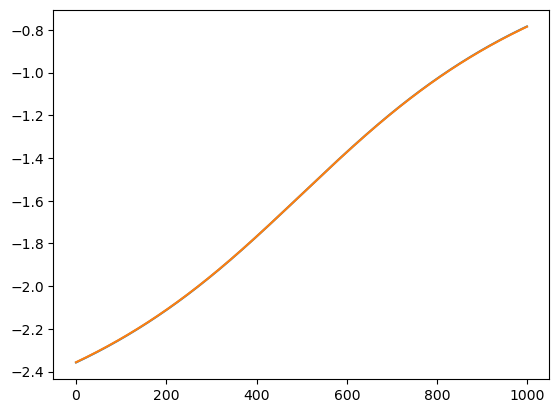

In [20]:
def xy_to_polar(x,y):
    return jnp.sqrt(x**2+y**2), jnp.arctan2(y,x)

x = jnp.linspace(-5,5,1000)
y = jnp.linspace(-5,5,1000)

X,Y = jnp.meshgrid(x,y)

r,theta = jax.vmap(xy_to_polar)(X,Y)
import matplotlib.pyplot as plt

plt.plot(theta[1,:])
plt.plot(theta[0,:])

# HO

In [1]:
import jax
import jax.numpy as jnp
import optax
from flax.training import train_state
from flax import linen as nn
from jax.scipy.integrate import trapezoid

In [2]:
# Define a simple MLP using Flax Linen
class MLP(nn.Module):
    architecture: list
    hidden_activation: callable = nn.tanh

    @nn.compact
    def __call__(self, x):
        for i in range(len(self.architecture) - 1):
            x = nn.Dense(features=self.architecture[i + 1])(x)
            if i < len(self.architecture) - 2:
                x = self.hidden_activation(x)
        return x
    
# Initialize model and parameters
model = MLP(architecture=[1, 2, 1])
print(model)
rng = jax.random.PRNGKey(0)
input_shape = (1000, 1)  # Batch size of 1000, input dimension
params = model.init(rng, jnp.ones(input_shape))  # Initialize parameters
print(params)

MLP(
    # attributes
    architecture = [1, 2, 1]
    hidden_activation = tanh
)
{'params': {'Dense_0': {'kernel': Array([[-1.6517997 ,  0.75455153]], dtype=float32), 'bias': Array([0., 0.], dtype=float32)}, 'Dense_1': {'kernel': Array([[0.00235284],
       [0.22645216]], dtype=float32), 'bias': Array([0.], dtype=float32)}}}


In [ ]:
def local_energy(x,params, model_apply): 
    psi = model_apply(params, x) # So that we don't compute twice the wavefunction, we could compute this with the log_psi
    kinetic = -0.5 * jnp.gradient(jnp.gradient(psi, x),x)
    potential = 0.5 * x**2
    return kinetic/psi + potential

def local_energy_batch(params, xs, model_apply, debug=False):
    def psi_fn(x):
        return model_apply(params, x)

    # get ψ(x) for the whole batch
    psi = jax.vmap(psi_fn)(xs)
    if debug:
        print(xs.shape)
        print(psi.shape)
        print(type(psi))

    # first and second derivative wrt x for the whole batch
    dpsi_dx = jnp.gradient(psi, xs.squeeze(), axis=0)
    d2psi_dx2 = jnp.gradient(dpsi_dx, xs.squeeze(), axis=0)

    kinetic = -0.5 * d2psi_dx2 / psi
    potential = (0.5 * xs**2).reshape(-1,1)
    if debug:
        print(kinetic.shape)
        print(potential.shape)
    return kinetic + potential

def log_psi(x, params, model_apply):
    psi = model_apply(params, x)
    return jnp.log(jnp.abs(psi) + 1e-8)  # Add small constant to avoid log(0)

grad_log_psi = jax.grad(lambda params, x, model_apply: log_psi(x, params, model_apply), argnums=0) # CAREFUL WITH THE DERIVATIVES: WE WANT THE GRADIENT WRT THE PARAMETERS, so we turn the order of the p and x

# now grad_log_psi is a function that takes (params, x, model_apply) and returns the gradient of log_psi wrt params

def log_psi_and_grad(params, x, model_apply):
    psi = model_apply(params, x)
    log_psi_val = jnp.log(jnp.abs(psi) + 1e-8)
    grad_log_psi_val = grad_log_psi(params, x, model_apply)
    return log_psi_val, grad_log_psi_val

def energy_fn(params, batch, model_apply):
    psi = jax.vmap(lambda x: model_apply(params, x))(batch)
    psi_squared = jnp.abs(psi)**2
    local_energy_per_point = local_energy_batch(params, batch, model_apply)

    # print(f"Psi squared shape: {psi_squared.shape}")
    # print(f"Local energy shape: {local_energy_per_point.shape}")

    energy_integrand = psi_squared * local_energy_per_point
    # print(f"Energy integrand shape: {energy_integrand.shape}")
    norm = trapezoid(psi_squared.squeeze(), batch.squeeze())
    # print(f"Norm shape: {norm.shape}, value: {norm}")
    integral = trapezoid(energy_integrand.squeeze(), batch.squeeze())
    # print(f"Integral shape: {integral.shape}, value: {integral}")
    return integral / norm 

def loss_and_grads(params, batch, model_apply):
    E = energy_fn(params, batch, model_apply)
    grad_E = jax.grad(energy_fn, argnums=0)(params, batch, model_apply)
    return E, grad_E

@jax.jit
def train_step(state, batch):
    E, grads = loss_and_grads(state.params, batch, state.apply_fn)
    new_state = state.apply_gradients(grads=grads)
    return new_state, E

def train(n_steps, init_params, model_apply, optimizer):

    state = train_state.TrainState.create(
        apply_fn=model_apply,
        params=init_params,
        tx=optimizer
    )

    energy_history = []
    batch = jnp.linspace(-5,5,1000).reshape(-1,1)

    for step in range(n_steps):
        # batch = sampler(state.params, state.apply_fn)
        state, energy = train_step(state, batch)
        energy_history.append(energy)

        if step % 100 == 0:
            print(f"Step {step}, Energy: {energy}")

    return state.params, energy_history

Step 0, Energy: 2.8549797534942627
Step 100, Energy: 0.8988254070281982
Step 200, Energy: 0.5831892490386963
Step 300, Energy: 0.5466018319129944
Step 400, Energy: 0.5308383703231812
Step 500, Energy: 0.5220752358436584
Step 600, Energy: 0.5162575244903564
Step 700, Energy: 0.5119786262512207
Step 800, Energy: 0.5087947249412537
Step 900, Energy: 0.5065177083015442


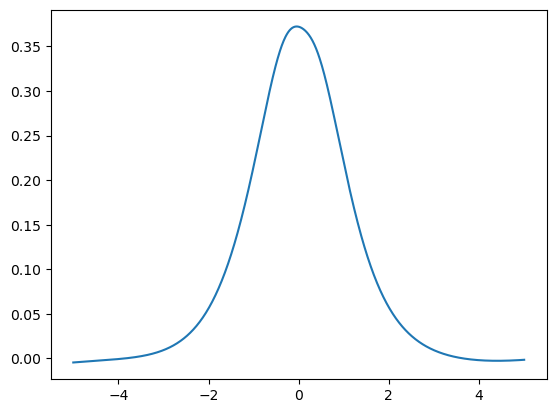

In [49]:
model = MLP(architecture=[1, 30, 1])
rng = jax.random.PRNGKey(0)
input_shape = (1000, 1)  # Batch size of 1000, input dimension
params = model.init(rng, jnp.ones(input_shape))  # Initialize parameters
params_fin, energy = train(1000, params, model.apply, optax.adam(1e-3))
import matplotlib.pyplot as plt
# plt.plot(energy)

# Reconstruct wavefunction
x = jnp.linspace(-5,5,1000).reshape(-1,1)
psi_approx = model.apply(params_fin, x)
plt.plot(x, psi_approx)

In [ ]:
def local_energy_batch(params, xs, model_apply, debug=False):
    def psi_fn(x):
        return model_apply(params, x)

    # get ψ(x) for the whole batch
    psi = jax.vmap(psi_fn)(xs)
    if debug:
        print(xs.shape)
        print(psi.shape)
        print(type(psi))

    # first and second derivative wrt x for the whole batch
    dpsi_dx = jnp.gradient(psi, xs.squeeze(), axis=0)
    d2psi_dx2 = jnp.gradient(dpsi_dx, xs.squeeze(), axis=0)

    kinetic = -0.5 * d2psi_dx2 / psi
    potential = (0.5 * xs**2).reshape(-1,1)
    if debug:
        print(kinetic.shape)
        print(potential.shape)
    return kinetic + potential

In [18]:
x = jnp.linspace(-5,5,1000).reshape(-1,1)
local_energy_batch(params, x, model.apply).shape


(1000, 1)
(1000, 1)
<class 'jaxlib._jax.ArrayImpl'>
(1000, 1)
(1000, 1)


(1000, 1)

In [10]:
# Example 1: Your specific case
print("1. Your case: (1000,) + (1000,1)")
a = jnp.ones((1000,))      # Shape: (1000,)
b = jnp.ones((1000, 1))    # Shape: (1000, 1)

print(f"a.shape = {a.shape}")
print(f"b.shape = {b.shape}")

result = a + b
print(f"(a + b).shape = {result.shape}")
print()

result2 = b + a
print(f"(b + a).shape = {result2.shape}")


1. Your case: (1000,) + (1000,1)
a.shape = (1000,)
b.shape = (1000, 1)
(a + b).shape = (1000, 1000)

(b + a).shape = (1000, 1000)


# SAMPLER